# 01 — Data Collection

**Projet** : Transmission de la politique monétaire de la BCE  
**Auteur** : ISLEYEN Volkan  
**Date** : Mai 2026

## Objectif

Ce notebook collecte l'ensemble des données nécessaires à l'analyse de l'impact 
des décisions de la BCE sur les marchés financiers européens entre 2019 et 2024.

## Sources utilisées

| Donnée | Source | Format |
|---|---|---|
| EURO STOXX 50 | Yahoo Finance (yfinance) | API |
| VSTOXX | Investing.com | CSV manuel |
| AAA 10Y zone euro | ECB Data Portal | API |
| Taux souverains nationaux (FR, IT, ES) | Investing.com | CSV manuel |
| Taux Refi BCE | ECB Data Portal | API |
| Dates décisions BCE | Compilation manuelle | hardcoded |

## Période d'étude

1er janvier 2019 → 31 décembre 2024 (6 ans, ~1500 jours ouvrés)

## Sortie

Tous les DataFrames sont sauvegardés en CSV dans `data/raw/` pour utilisation 
par le notebook 02 (nettoyage et calculs).

## 1. Setup et imports

Chargement des librairies et définition des paramètres globaux (période d'étude, chemins).
La période **2019-2024** couvre le cycle complet de la politique monétaire BCE :
phase ultra-accommodante (taux négatifs jusqu'en juillet 2022), cycle de hausses 
(juillet 2022 → septembre 2023, +450 bp cumulés), puis amorce du cycle de baisses (juin 2024).

In [31]:
# Librairies essentielles
import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
import warnings
print("Setup OK")

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Vérification
print("Librairies importées avec succès")

Setup OK
Librairies importées avec succès


In [2]:
# Période d'étude
START_DATE = "2019-01-01"
END_DATE = "2024-12-31"

# Chemin de sauvegarde des données brutes
DATA_PATH = "../data/raw/"

print(f"Période d'étude : {START_DATE} → {END_DATE}")
print(f"Données sauvegardées dans : {DATA_PATH}")

Période d'étude : 2019-01-01 → 2024-12-31
Données sauvegardées dans : ../data/raw/


## 2. EURO STOXX 50

L'indice de référence des grandes capitalisations boursières de la zone euro,
utilisé comme proxy de la performance des actions européennes dans l'event study.
Données quotidiennes via Yahoo Finance (ticker `^STOXX50E`).

In [3]:
# Téléchargement EURO STOXX 50 via yfinance
# Ticker Yahoo Finance : ^STOXX50E
print("Téléchargement EURO STOXX 50...")

sx5e = yf.download("^STOXX50E", start=START_DATE, end=END_DATE, progress=False)
sx5e = sx5e[['Close']].rename(columns={'Close': 'SX5E'})

# Aperçu
print(f"\nNombre de lignes : {len(sx5e)}")
print(f"Période effective : {sx5e.index.min().date()} → {sx5e.index.max().date()}")
print("\nPremières lignes :")
sx5e.head()

Téléchargement EURO STOXX 50...

Nombre de lignes : 1510
Période effective : 2019-01-03 → 2024-12-30

Premières lignes :


Price,SX5E
Ticker,^STOXX50E
Date,
2019-01-03,2954.659912
2019-01-04,3041.850098
2019-01-07,3033.639893
2019-01-08,3054.939941
2019-01-09,3070.239990


In [4]:
# Diagnostic : où Jupyter cherche-t-il le .env ?
import os
from pathlib import Path

# Où se trouve le notebook ?
print("Dossier de travail actuel :", os.getcwd())

# Le fichier .env existe-t-il à l'emplacement attendu ?
env_path = Path("../.env").resolve()
print(f"Chemin résolu pour .env : {env_path}")
print(f"Le fichier existe ? {env_path.exists()}")

# Lister les fichiers du dossier parent (avec les cachés)
parent = Path("..").resolve()
print(f"\nContenu de {parent} :")
for f in sorted(parent.iterdir()):
    print(f"  - {f.name}")

Dossier de travail actuel : C:\Users\volka\Documents\ecb-monetary-policy-transmission
Chemin résolu pour .env : C:\Users\volka\Documents\.env
Le fichier existe ? False

Contenu de C:\Users\volka\Documents :
  - ecb-monetary-policy-transmission
  - Ma musique
  - Mes images
  - Mes vidéos


## 3. VSTOXX

Le VSTOXX mesure la volatilité implicite à 30 jours sur les options EURO STOXX 50.
C'est l'équivalent européen du VIX — souvent appelé "fear gauge" zone euro.
Il nous permettra d'analyser comment la volatilité réagit aux annonces BCE.

Données téléchargées manuellement depuis Investing.com et placées dans `data/raw/vstoxx.csv`,
car Yahoo Finance, FRED et Stooq ne fournissent plus cette série de façon fiable.

In [13]:
# Téléchargement VSTOXX via CSV local (Investing.com)
import os
from dotenv import load_dotenv

# Charger la clé API FRED
load_dotenv(".env")
FRED_API_KEY = os.getenv("FRED_API_KEY")

if FRED_API_KEY:
    print(f" Clé FRED chargée (longueur : {len(FRED_API_KEY)} caractères)")
    fred = Fred(api_key=FRED_API_KEY)

# Lecture du fichier VSTOXX local
print("\nLecture du VSTOXX depuis le fichier local...")

vstoxx_raw = pd.read_csv("data/raw/vstoxx.csv")

# Nettoyage
# 1. Parser les dates (format américain MM/DD/YYYY)
vstoxx_raw["Date"] = pd.to_datetime(vstoxx_raw["Date"], format="%m/%d/%Y")

# 2. On garde uniquement Date et Price, renommé en VSTOXX
vstoxx = vstoxx_raw[["Date", "Price"]].copy()
vstoxx = vstoxx.rename(columns={"Price": "VSTOXX"})

# 3. Mettre Date en index et trier en ordre chronologique
vstoxx = vstoxx.set_index("Date").sort_index()

# 4. Filtrer sur la période d'étude (sécurité)
vstoxx = vstoxx.loc[START_DATE:END_DATE]
vstoxx = vstoxx.dropna()

# Aperçu
print(f"\nNombre de lignes : {len(vstoxx)}")
print(f"Période effective : {vstoxx.index.min().date()} → {vstoxx.index.max().date()}")
print("\nPremières lignes :")
print(vstoxx.head())
print("\nDernières lignes :")
print(vstoxx.tail())
print(f"\nStatistiques descriptives :")
print(vstoxx.describe())

 Clé FRED chargée (longueur : 32 caractères)

Lecture du VSTOXX depuis le fichier local...

Nombre de lignes : 1536
Période effective : 2019-01-02 → 2024-12-30

Premières lignes :
            VSTOXX
Date              
2019-01-02   23.39
2019-01-03   23.00
2019-01-04   20.48
2019-01-07   20.15
2019-01-08   19.48

Dernières lignes :
            VSTOXX
Date              
2024-12-19   18.63
2024-12-20   16.84
2024-12-23   17.19
2024-12-27   16.27
2024-12-30   17.00

Statistiques descriptives :
            VSTOXX
count  1536.000000
mean     20.809766
std       8.108062
min      10.690000
25%      15.447500
50%      18.755000
75%      23.770000
max      85.620000


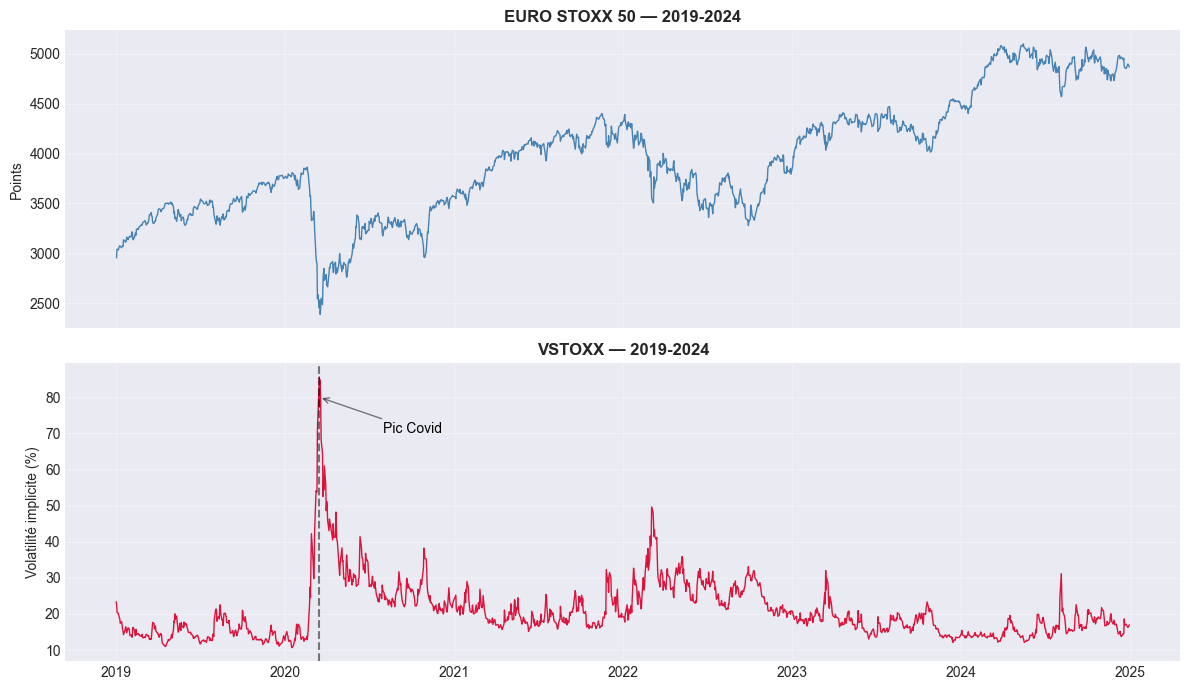

In [34]:
# Visualisation graphique STOXX 50 + VSTOXX
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# EURO STOXX 50
axes[0].plot(sx5e.index, sx5e['SX5E'], color='steelblue', linewidth=1)
axes[0].set_title('EURO STOXX 50 — 2019-2024', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Points')
axes[0].grid(True, alpha=0.3)

# VSTOXX
axes[1].plot(vstoxx.index, vstoxx['VSTOXX'], color='crimson', linewidth=1)
axes[1].set_title('VSTOXX — 2019-2024', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatilité implicite (%)')
axes[1].grid(True, alpha=0.3)

# Marquer le pic Covid pour le contexte
axes[1].axvline(pd.Timestamp("2020-03-16"), color='black', linestyle='--', alpha=0.5)
axes[1].annotate('Pic Covid', xy=(pd.Timestamp("2020-03-16"), 80),
                 xytext=(pd.Timestamp("2020-08-01"), 70),
                 fontsize=10, color='black',
                 arrowprops=dict(arrowstyle='->', color='black', alpha=0.5))

plt.tight_layout()
plt.show()

**En haut** : la courbe du STOXX 50 avec le creux marqué de mars 2020 (Covid), puis la baisse plus douce de 2022 (Ukraine + hausses BCE), puis la reprise

**En bas** : le VSTOXX avec un pic spectaculaire à 85 en mars 2020, puis des pics plus modestes en 2022 et un retour au calme

## 4. Taux souverains 10 ans

Trois éléments :

1. **AAA zone euro** (proxy du Bund) — courbe officielle BCE, API quotidienne
2. **France, Italie, Espagne** — taux nationaux 10 ans (Investing.com)
3. **Spreads** : différence entre chaque taux national et l'AAA, exprimée en points de base

Le **spread italien (BTP-AAA)** est l'indicateur classique du stress souverain zone euro
et constituera l'un des principaux objets d'analyse de l'event study.

In [35]:
# Téléchargement taux 10 ans AAA zone euro via API BCE
import requests
from io import StringIO

print("Téléchargement courbe AAA 10 ans (zone euro) via API BCE...")

url_aaa10y = "https://data-api.ecb.europa.eu/service/data/YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y"

response = requests.get(url_aaa10y, params={"format": "csvdata"})

# Lecture du CSV depuis la réponse
aaa_raw = pd.read_csv(StringIO(response.text))

# On ne garde que ce qui nous intéresse : date et valeur
aaa10y = aaa_raw[["TIME_PERIOD", "OBS_VALUE"]].copy()
aaa10y.columns = ["Date", "AAA_10Y"]

# Conversion de la date et mise en index
aaa10y["Date"] = pd.to_datetime(aaa10y["Date"])
aaa10y = aaa10y.set_index("Date").sort_index()

# Filtrer sur la période d'étude
aaa10y = aaa10y.loc[START_DATE:END_DATE]
aaa10y = aaa10y.dropna()

# Aperçu
print(f"\nNombre de lignes : {len(aaa10y)}")
print(f"Période effective : {aaa10y.index.min().date()} → {aaa10y.index.max().date()}")
print("\nPremières lignes :")
print(aaa10y.head())
print("\nDernières lignes :")
print(aaa10y.tail())
print(f"\nStatistiques descriptives :")
print(aaa10y.describe())

Téléchargement courbe AAA 10 ans (zone euro) via API BCE...

Nombre de lignes : 1532
Période effective : 2019-01-02 → 2024-12-30

Premières lignes :
             AAA_10Y
Date                
2019-01-02  0.227773
2019-01-03  0.246228
2019-01-04  0.274661
2019-01-07  0.288875
2019-01-08  0.310582

Dernières lignes :
             AAA_10Y
Date                
2024-12-20  2.374684
2024-12-23  2.402344
2024-12-24  2.405459
2024-12-27  2.431800
2024-12-30  2.447304

Statistiques descriptives :
           AAA_10Y
count  1532.000000
mean      0.884127
std       1.304101
min      -0.815215
25%      -0.324132
50%       0.191346
75%       2.363076
max       3.033350


In [36]:
# Lecture des taux souverains 10 ans : France, Italie, Espagne
# Fichiers Investing.com téléchargés manuellement dans data/raw/

print("Lecture des taux souverains nationaux...\n")

# Dictionnaire : nom de fichier → nom de colonne final
fichiers_taux = {
    "france_10y.csv": "FR_10Y",
    "italy_10y.csv":  "IT_10Y",
    "spain_10y.csv":  "ES_10Y",
}

# DataFrame de consolidation
taux_nationaux = pd.DataFrame()

for fichier, nom_col in fichiers_taux.items():
    chemin = f"data/raw/{fichier}"
    
    # Lecture du CSV brut
    df = pd.read_csv(chemin)
    
    # Parsing date (format Investing.com : MM/DD/YYYY)
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
    
    # On garde uniquement Date et Price (le taux de clôture)
    df = df[["Date", "Price"]].rename(columns={"Price": nom_col})
    df = df.set_index("Date").sort_index()
    
    # Fusion progressive dans le DataFrame consolidé
    if taux_nationaux.empty:
        taux_nationaux = df
    else:
        taux_nationaux = taux_nationaux.join(df, how="outer")
    
    print(f" ✓ {fichier} → {nom_col} ({len(df)} lignes)")

# Filtrer sur la période d'étude
taux_nationaux = taux_nationaux.loc[START_DATE:END_DATE]

# Jonction avec l'AAA 10Y (déjà chargé en mémoire)
taux_souverains = taux_nationaux.join(aaa10y, how="inner")

# Calcul des spreads vs AAA zone euro (en points de base)
taux_souverains["spread_FR"] = (taux_souverains["FR_10Y"] - taux_souverains["AAA_10Y"]) * 100
taux_souverains["spread_IT"] = (taux_souverains["IT_10Y"] - taux_souverains["AAA_10Y"]) * 100
taux_souverains["spread_ES"] = (taux_souverains["ES_10Y"] - taux_souverains["AAA_10Y"]) * 100

# Aperçu final
print(f"\n DataFrame consolidé : {taux_souverains.shape}")
print(f"Période : {taux_souverains.index.min().date()} → {taux_souverains.index.max().date()}")
print("\nPremières lignes :")
print(taux_souverains.head())
print("\nStatistiques descriptives des spreads (en bp) :")
print(taux_souverains[["spread_FR", "spread_IT", "spread_ES"]].describe().round(1))

Lecture des taux souverains nationaux...

 ✓ france_10y.csv → FR_10Y (1610 lignes)
 ✓ italy_10y.csv → IT_10Y (1668 lignes)
 ✓ spain_10y.csv → ES_10Y (1638 lignes)

 DataFrame consolidé : (1532, 7)
Période : 2019-01-02 → 2024-12-30

Premières lignes :
            FR_10Y  IT_10Y  ES_10Y   AAA_10Y  spread_FR   spread_IT  \
Date                                                                  
2019-01-02   0.656   2.691   1.407  0.227773  42.822683  246.322683   
2019-01-03   0.656   2.888   1.438  0.246228  40.977242  264.177242   
2019-01-04   0.695   2.892   1.478  0.274661  42.033882  261.733882   
2019-01-07   0.721   2.904   1.507  0.288875  43.212517  261.512517   
2019-01-08   0.737   2.965   1.527  0.310582  42.641821  265.441821   

             spread_ES  
Date                    
2019-01-02  117.922683  
2019-01-03  119.177242  
2019-01-04  120.333882  
2019-01-07  121.812517  
2019-01-08  121.641821  

Statistiques descriptives des spreads (en bp) :
       spread_FR  spread_IT


**Le spread italien** à __285 bp__ en pic correspond probablement à mi-2022 (crise énergétique + hausses BCE + instabilité politique Italie). C'est le moment de tension maximale sur les souverains zone euro pendant ta période — exactement le genre d'événement qu'un event study capture bien.

Et la hiérarchie FR < ES < IT est parfaite : c'est la signature classique du risque souverain européen.

## 5. Politique monétaire BCE

Deux éléments complémentaires :

- **Taux Refi quotidien** (API BCE) — taux de refinancement principal, principal taux directeur
- **Liste des décisions de politique monétaire** 2019-2024, avec amplitude en bp et contexte

Au total, 18 décisions sont compilées : 10 hausses, 4 baisses, 4 "holds" marquants 
(QE relancé en 2019, PEPP en 2020, recalibrage 2021).

In [37]:
# Téléchargement taux Refi BCE via API
print("Téléchargement taux Refi BCE...")

# Dataset FM, série du taux de refinancement principal (MRO)
url_refi = "https://data-api.ecb.europa.eu/service/data/FM/D.U2.EUR.4F.KR.MRR_FR.LEV"

response = requests.get(url_refi, params={"format": "csvdata"})

print(f"Statut HTTP : {response.status_code}")
print(f"Taille de la réponse : {len(response.text)} caractères")

# Lecture
refi_raw = pd.read_csv(StringIO(response.text))

# On garde ce qui nous intéresse
refi = refi_raw[["TIME_PERIOD", "OBS_VALUE"]].copy()
refi.columns = ["Date", "Refi"]
refi["Date"] = pd.to_datetime(refi["Date"])
refi = refi.set_index("Date").sort_index()

# Filtrer sur la période
refi = refi.loc[START_DATE:END_DATE]
refi = refi.dropna()

print(f"\n Taux Refi BCE : {len(refi)} lignes")
print(f"Période : {refi.index.min().date()} → {refi.index.max().date()}")
print("\nPremières lignes :")
print(refi.head())
print("\nValeurs uniques observées (les changements de taux) :")
print(refi["Refi"].value_counts().sort_index())

Téléchargement taux Refi BCE...
Statut HTTP : 200
Taille de la réponse : 2579430 caractères

 Taux Refi BCE : 2192 lignes
Période : 2019-01-01 → 2024-12-31

Premières lignes :
            Refi
Date            
2019-01-01   0.0
2019-01-02   0.0
2019-01-03   0.0
2019-01-04   0.0
2019-01-05   0.0

Valeurs uniques observées (les changements de taux) :
Refi
0.00    1303
0.50      49
1.25      49
2.00      49
2.50      49
3.00      42
3.15      14
3.40      56
3.50      49
3.65      35
3.75      42
4.00      42
4.25     147
4.50     266
Name: count, dtype: int64


In [38]:
# Dates des décisions de politique monétaire BCE 2019-2024
# Source : ECB Press Releases (https://www.ecb.europa.eu/press/pr/date/)
# Format : date_décision : (variation_taux_refi_en_bp, label)

decisions_bce = {
    # ─── 2019 ─── Phase de taux négatifs / dépôts négatifs
    "2019-09-12": (0,   "Hold (QE relancé)"),
    
    # ─── 2020 ─── Pandémie : PEPP et liquidité, pas de mouvement sur Refi
    "2020-03-12": (0,   "Hold (PEPP annoncé)"),
    "2020-06-04": (0,   "Hold (PEPP étendu)"),
    
    # ─── 2021 ─── Stabilité avant inflation
    "2021-12-16": (0,   "Hold (PEPP recalibré)"),
    
    # ─── 2022 ─── Démarrage du cycle de hausses (historique)
    "2022-07-21": (+50, "Hike +50 bp (fin taux négatifs)"),
    "2022-09-08": (+75, "Hike +75 bp"),
    "2022-10-27": (+75, "Hike +75 bp"),
    "2022-12-15": (+50, "Hike +50 bp"),
    
    # ─── 2023 ─── Poursuite du resserrement
    "2023-02-02": (+50, "Hike +50 bp"),
    "2023-03-16": (+50, "Hike +50 bp"),
    "2023-05-04": (+25, "Hike +25 bp"),
    "2023-06-15": (+25, "Hike +25 bp"),
    "2023-07-27": (+25, "Hike +25 bp"),
    "2023-09-14": (+25, "Hike +25 bp (dernier du cycle)"),
    
    # ─── 2024 ─── Début du cycle de baisses
    "2024-06-06": (-25, "Cut -25 bp (1er du cycle baissier)"),
    "2024-09-12": (-25, "Cut -25 bp"),
    "2024-10-17": (-25, "Cut -25 bp"),
    "2024-12-12": (-25, "Cut -25 bp"),
}

# Construction du DataFrame
bce_events = pd.DataFrame(
    [(date, change, label) for date, (change, label) in decisions_bce.items()],
    columns=["Date", "Change_bp", "Description"]
)
bce_events["Date"] = pd.to_datetime(bce_events["Date"])
bce_events = bce_events.set_index("Date").sort_index()

# Aperçu
print(f" Nombre de décisions BCE compilées : {len(bce_events)}")
print(f"Période : {bce_events.index.min().date()} → {bce_events.index.max().date()}\n")
print("Liste complète :")
print(bce_events.to_string())

print(f"\n Résumé :")
print(f"  - Hausses (>0) : {(bce_events['Change_bp'] > 0).sum()}")
print(f"  - Baisses (<0) : {(bce_events['Change_bp'] < 0).sum()}")
print(f"  - Holds (=0)   : {(bce_events['Change_bp'] == 0).sum()}")
print(f"  - Variation cumulée : {bce_events['Change_bp'].sum():+d} bp")

 Nombre de décisions BCE compilées : 18
Période : 2019-09-12 → 2024-12-12

Liste complète :
            Change_bp                         Description
Date                                                     
2019-09-12          0                   Hold (QE relancé)
2020-03-12          0                 Hold (PEPP annoncé)
2020-06-04          0                  Hold (PEPP étendu)
2021-12-16          0               Hold (PEPP recalibré)
2022-07-21         50     Hike +50 bp (fin taux négatifs)
2022-09-08         75                         Hike +75 bp
2022-10-27         75                         Hike +75 bp
2022-12-15         50                         Hike +50 bp
2023-02-02         50                         Hike +50 bp
2023-03-16         50                         Hike +50 bp
2023-05-04         25                         Hike +25 bp
2023-06-15         25                         Hike +25 bp
2023-07-27         25                         Hike +25 bp
2023-09-14         25      Hike +25 bp

In [39]:
# Sauvegarde de toutes les données collectées
import os

# S'assurer que le dossier existe
os.makedirs("data/raw", exist_ok=True)

# Liste des DataFrames à sauvegarder
datasets = {
    "sx5e.csv":            sx5e,
    "vstoxx_clean.csv":    vstoxx,
    "aaa_10y.csv":         aaa10y,
    "taux_souverains.csv": taux_souverains,
    "refi.csv":            refi,
    "bce_events.csv":      bce_events,
}

print(" Sauvegarde des données dans data/raw/ ...\n")

for nom_fichier, df in datasets.items():
    chemin = f"data/raw/{nom_fichier}"
    df.to_csv(chemin, encoding="utf-8")
    print(f"  ✓ {nom_fichier:25s} → {len(df):>5} lignes, {df.shape[1]} colonnes")

print(f"\n Notebook 01 terminé — toutes les données sont sauvegardées.")

 Sauvegarde des données dans data/raw/ ...

  ✓ sx5e.csv                  →  1510 lignes, 1 colonnes
  ✓ vstoxx_clean.csv          →  1536 lignes, 1 colonnes
  ✓ aaa_10y.csv               →  1532 lignes, 1 colonnes
  ✓ taux_souverains.csv       →  1532 lignes, 7 colonnes
  ✓ refi.csv                  →  2192 lignes, 1 colonnes
  ✓ bce_events.csv            →    18 lignes, 2 colonnes

 Notebook 01 terminé — toutes les données sont sauvegardées.
